## Load and Display Data

In [ ]:
import pandas as pd

df = pd.read_csv('/content/students_dropout_academic_success.csv')

print("First 5 rows of the dataset:")
print(df.head())

print("\nColumn names and their data types:")
df.info()

print("\nDescriptive statistics for the dataset:")
print(df.describe())

First 5 rows of the dataset:
   Marital Status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2        

## Analyze Potential Target Variables


In [ ]:
print("Unique values and their counts for the 'target' column:")
print(df['target'].value_counts())


Unique values and their counts for the 'target' column:
target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## Data Overview and Summary

In [ ]:
print(f"The DataFrame has {df.shape[0]} rows and {df.shape[1]} columns.")

The DataFrame has 4424 rows and 37 columns.


In [ ]:
print("\nInformation about the DataFrame (data types, non-null values, memory usage):")
df.info()


Information about the DataFrame (data types, non-null values, memory usage):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                  

In [ ]:
print("\nDescriptive statistics for the dataset:")
print(df.describe())


Descriptive statistics for the dataset:
       Marital Status  Application mode  Application order       Course  \
count     4424.000000       4424.000000        4424.000000  4424.000000   
mean         1.178571         18.669078           1.727848  8856.642631   
std          0.605747         17.484682           1.313793  2063.566416   
min          1.000000          1.000000           0.000000    33.000000   
25%          1.000000          1.000000           1.000000  9085.000000   
50%          1.000000         17.000000           1.000000  9238.000000   
75%          1.000000         39.000000           2.000000  9556.000000   
max          6.000000         57.000000           9.000000  9991.000000   

       Daytime/evening attendance  Previous qualification  \
count                 4424.000000             4424.000000   
mean                     0.890823                4.577758   
std                      0.311897               10.216592   
min                      0.000000      

## Missing Values Analysis



In [ ]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if missing_info.empty:
    print("No missing values found in the dataset.")
else:
    print("Missing values in each column:")
    print(missing_info)


No missing values found in the dataset.


## Outlier Detection (Numerical Features)



In [ ]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Exclude columns identified as categorical or count/code-based, or the target column
# The target column is already excluded by dtypes, but good to be explicit if it was numerical
exclude_cols = [
    'Marital Status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification", "Mother's occupation",
    "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment',
    'International',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (without evaluations)'
]

# Filter out the excluded columns
# Also explicitly exclude 'target' just in case, though it's an object type
numerical_for_outliers = [col for col in numerical_cols if col not in exclude_cols and col != 'target']

print("Numerical columns selected for outlier detection:")
print(numerical_for_outliers)


Numerical columns selected for outlier detection:
['Previous qualification (grade)', 'Admission grade', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)', 'Unemployment rate', 'Inflation rate', 'GDP']


In [ ]:
print("Descriptive statistics for numerical columns selected for outlier detection:")
print(df[numerical_for_outliers].describe())

Descriptive statistics for numerical columns selected for outlier detection:
       Previous qualification (grade)  Admission grade  \
count                     4424.000000      4424.000000   
mean                       132.613314       126.978119   
std                         13.188332        14.482001   
min                         95.000000        95.000000   
25%                        125.000000       117.900000   
50%                        133.100000       126.100000   
75%                        140.000000       134.800000   
max                        190.000000       190.000000   

       Curricular units 1st sem (grade)  Curricular units 2nd sem (grade)  \
count                       4424.000000                       4424.000000   
mean                          10.640822                         10.230206   
std                            4.843663                          5.210808   
min                            0.000000                          0.000000   
25%            

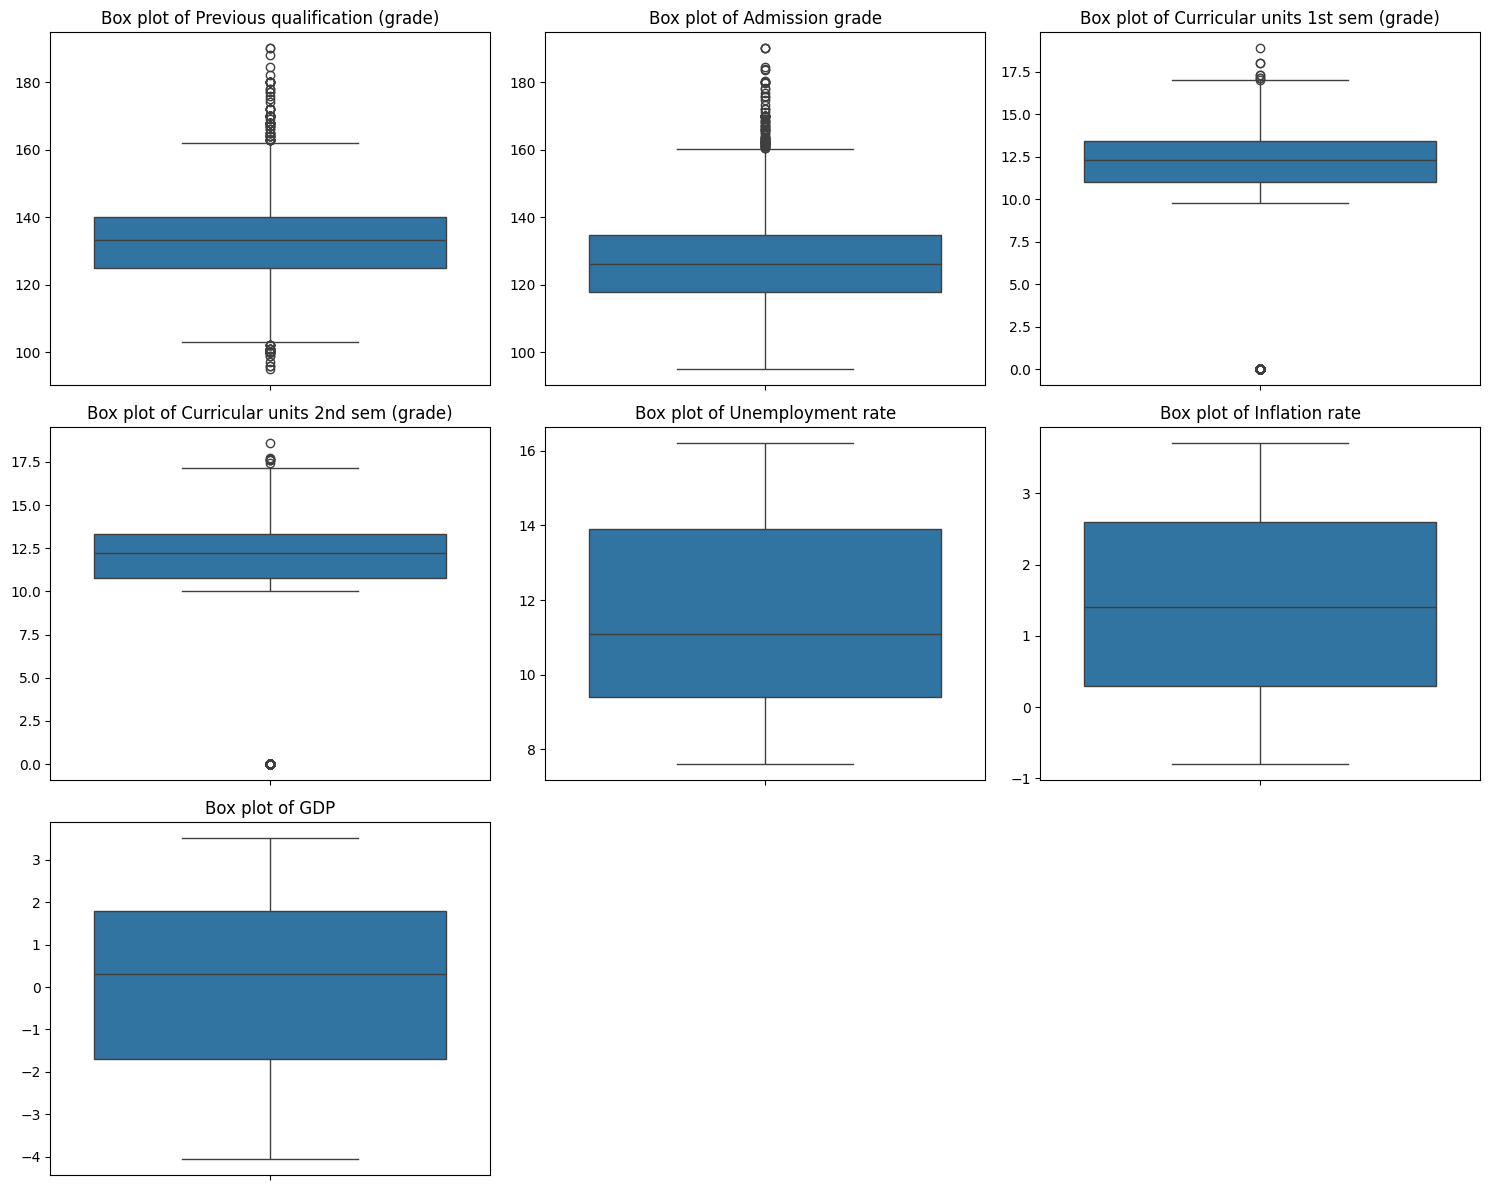

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Determine the number of rows and columns for the subplots
n_cols = 3  # For example, 3 columns per row
n_rows = (len(numerical_for_outliers) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(numerical_for_outliers):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel('') # Remove y-label to avoid clutter
plt.tight_layout()
plt.show()


## Data Dictionary Generation



In [ ]:
data_dictionary = {
    'Marital Status': {'data_type': 'int64', 'description': 'Categorical: Marital status of the student (e.g., single, married). Specific codes are not provided, but typically represent different statuses.'},
    'Application mode': {'data_type': 'int64', 'description': 'Categorical: Mode of application (e.g., 1st phase, 2nd phase). Specific codes are not provided, but each number represents a different application method.'},
    'Application order': {'data_type': 'int64', 'description': 'Ordinal: Order of application (e.g., 1st, 2nd, 3rd choice). Higher numbers indicate a lower preference for the course.'},
    'Course': {'data_type': 'int64', 'description': 'Categorical: Course code. Each number corresponds to a specific academic program.'},
    'Daytime/evening attendance': {'data_type': 'int64', 'description': 'Binary: 1 for daytime attendance, 0 for evening attendance.'},
    'Previous qualification': {'data_type': 'int64', 'description': 'Categorical: Previous academic qualification (e.g., high school, bachelor). Specific codes are not provided.'},
    'Previous qualification (grade)': {'data_type': 'float64', 'description': 'Numerical: Grade obtained in previous academic qualification.'},
    'Nacionality': {'data_type': 'int64', 'description': 'Categorical: Nationality of the student. Specific codes are not provided.'},
    "Mother's qualification": {'data_type': 'int64', 'description': 'Categorical: Qualification of the student\'s mother. Specific codes are not provided.'},
    "Father's qualification": {'data_type': 'int64', 'description': 'Categorical: Qualification of the student\'s father. Specific codes are not provided.'},
    "Mother's occupation": {'data_type': 'int64', 'description': 'Categorical: Occupation of the student\'s mother. Specific codes are not provided.'},
    "Father's occupation": {'data_type': 'int64', 'description': 'Categorical: Occupation of the student\'s father. Specific codes are not provided.'},
    'Admission grade': {'data_type': 'float64', 'description': 'Numerical: Grade obtained in the admission process.'},
    'Displaced': {'data_type': 'int64', 'description': 'Binary: Whether the student is displaced (1 if yes, 0 if no). This could refer to living away from home for studies.'},
    'Educational special needs': {'data_type': 'int64', 'description': 'Binary: Whether the student has special educational needs (1 if yes, 0 if no).'},
    'Debtor': {'data_type': 'int64', 'description': 'Binary: Whether the student is a debtor (1 if yes, 0 if no). Likely refers to outstanding tuition fees or other financial obligations.'},
    'Tuition fees up to date': {'data_type': 'int64', 'description': 'Binary: Whether the student has paid tuition fees up to date (1 if yes, 0 if no).'},
    'Gender': {'data_type': 'int64', 'description': 'Binary: Gender of the student (e.g., 1 for male, 0 for female or vice-versa). Specific mapping is unknown.'},
    'Scholarship holder': {'data_type': 'int64', 'description': 'Binary: Whether the student is a scholarship holder (1 if yes, 0 if no).'},
    'Age at enrollment': {'data_type': 'int64', 'description': 'Numerical: Age of the student at the time of enrollment.'},
    'International': {'data_type': 'int64', 'description': 'Binary: Whether the student is an international student (1 if yes, 0 if no).'},
    'Curricular units 1st sem (credited)': {'data_type': 'int64', 'description': 'Numerical: Number of curricular units credited in the 1st semester.'},
    'Curricular units 1st sem (enrolled)': {'data_type': 'int64', 'description': 'Numerical: Number of curricular units enrolled in the 1st semester.'},
    'Curricular units 1st sem (evaluations)': {'data_type': 'int64', 'description': 'Numerical: Number of evaluations performed in the 1st semester curricular units.'},
    'Curricular units 1st sem (approved)': {'data_type': 'int64', 'description': 'Numerical: Number of curricular units approved in the 1st semester.'},
    'Curricular units 1st sem (grade)': {'data_type': 'float64', 'description': 'Numerical: Average grade obtained in the 1st semester curricular units.'},
    'Curricular units 1st sem (without evaluations)': {'data_type': 'int64', 'description': 'Numerical: Number of curricular units in the 1st semester without evaluations.'},
    'Curricular units 2nd sem (credited)': {'data_type': 'int64', 'description': 'Numerical: Number of curricular units credited in the 2nd semester.'},
    'Curricular units 2nd sem (enrolled)': {'data_type': 'int64', 'description': 'Numerical: Number of curricular units enrolled in the 2nd semester.'},
    'Curricular units 2nd sem (evaluations)': {'data_type': 'int64', 'description': 'Numerical: Number of evaluations performed in the 2nd semester curricular units.'},
    'Curricular units 2nd sem (approved)': {'data_type': 'int64', 'description': 'Numerical: Number of curricular units approved in the 2nd semester.'},
    'Curricular units 2nd sem (grade)': {'data_type': 'float64', 'description': 'Numerical: Average grade obtained in the 2nd semester curricular units.'},
    'Curricular units 2nd sem (without evaluations)': {'data_type': 'int64', 'description': 'Numerical: Number of curricular units in the 2nd semester without evaluations.'},
    'Unemployment rate': {'data_type': 'float64', 'description': 'Numerical: Unemployment rate in the period of enrollment (contextual socio-economic factor).'},
    'Inflation rate': {'data_type': 'float64', 'description': 'Numerical: Inflation rate in the period of enrollment (contextual socio-economic factor).'},
    'GDP': {'data_type': 'float64', 'description': 'Numerical: Gross Domestic Product in the period of enrollment (contextual socio-economic factor).'},
    'target': {'data_type': 'object', 'description': 'Categorical: The academic outcome of the student. Possible values: \'Graduate\', \'Dropout\', \'Enrolled\'. This is the target variable for prediction.'}
}

print("### Data Dictionary")
for column, details in data_dictionary.items():
    print(f"\n- **{column}**:")
    print(f"  - Data Type: {details['data_type']}")
    print(f"  - Description: {details['description']}")


### Data Dictionary

- **Marital Status**:
  - Data Type: int64
  - Description: Categorical: Marital status of the student (e.g., single, married). Specific codes are not provided, but typically represent different statuses.

- **Application mode**:
  - Data Type: int64
  - Description: Categorical: Mode of application (e.g., 1st phase, 2nd phase). Specific codes are not provided, but each number represents a different application method.

- **Application order**:
  - Data Type: int64
  - Description: Ordinal: Order of application (e.g., 1st, 2nd, 3rd choice). Higher numbers indicate a lower preference for the course.

- **Course**:
  - Data Type: int64
  - Description: Categorical: Course code. Each number corresponds to a specific academic program.

- **Daytime/evening attendance**:
  - Data Type: int64
  - Description: Binary: 1 for daytime attendance, 0 for evening attendance.

- **Previous qualification**:
  - Data Type: int64
  - Description: Categorical: Previous academic quali

In [ ]:
data_dictionary_df = pd.DataFrame.from_dict(data_dictionary, orient='index')
data_dictionary_df.index.name = 'Feature'
display(data_dictionary_df)

,data_type,description
Feature,,
Marital Status,int64,Categorical: Marital status of the student (e....
Application mode,int64,"Categorical: Mode of application (e.g., 1st ph..."
Application order,int64,"Ordinal: Order of application (e.g., 1st, 2nd,..."
Course,int64,Categorical: Course code. Each number correspo...
Daytime/evening attendance,int64,"Binary: 1 for daytime attendance, 0 for evenin..."
Previous qualification,int64,Categorical: Previous academic qualification (...
Previous qualification (grade),float64,Numerical: Grade obtained in previous academic...
Nacionality,int64,Categorical: Nationality of the student. Speci...
Mother's qualification,int64,Categorical: Qualification of the student's mo...


## Identify Categorical Features


In [ ]:
object_cols = df.select_dtypes(include='object').columns.tolist()

# Identify int64 columns that are categorical codes
# Based on the data dictionary, these are the columns where unique values represent categories
# and are not continuous numbers like grades or counts of curricular units.
int_categorical_cols = [
    'Marital Status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification", "Mother's occupation",
    "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International'
]

# Combine all identified categorical columns
categorical_features = int_categorical_cols

# Ensure 'target' is not in the list, though it's already excluded by explicit listing
if 'target' in categorical_features:
    categorical_features.remove('target')

print("Identified categorical features (excluding 'target'):")
print(categorical_features)

Identified categorical features (excluding 'target'):
['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']


## Generate Histograms for Numerical Features



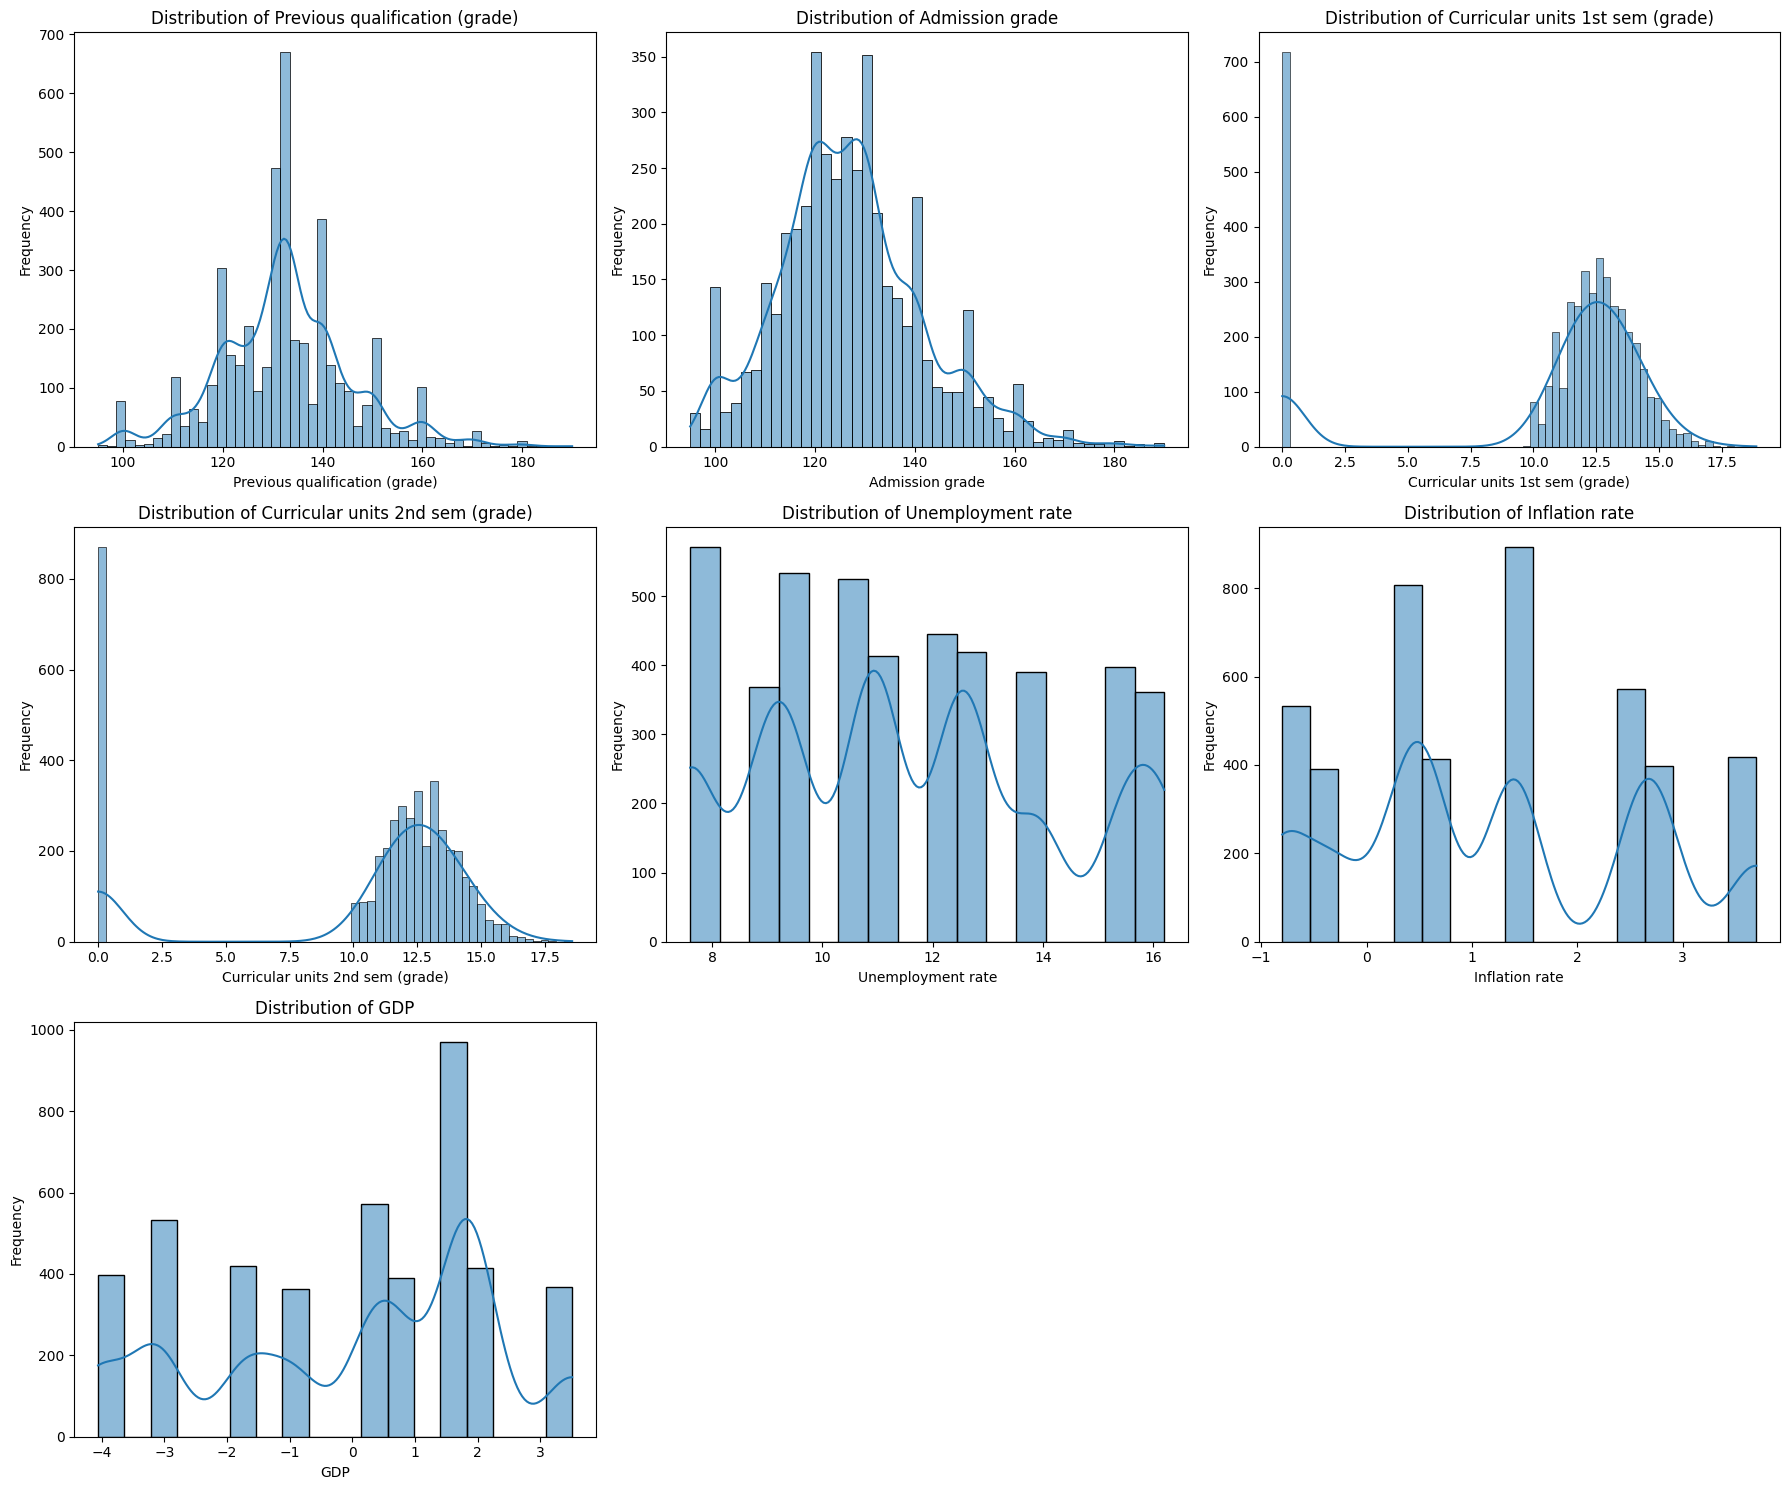

In [ ]:
n_cols = 3  # Number of columns for the grid
n_rows = (len(numerical_for_outliers) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 5))
for i, col in enumerate(numerical_for_outliers):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Generate Count Plots for Categorical Features



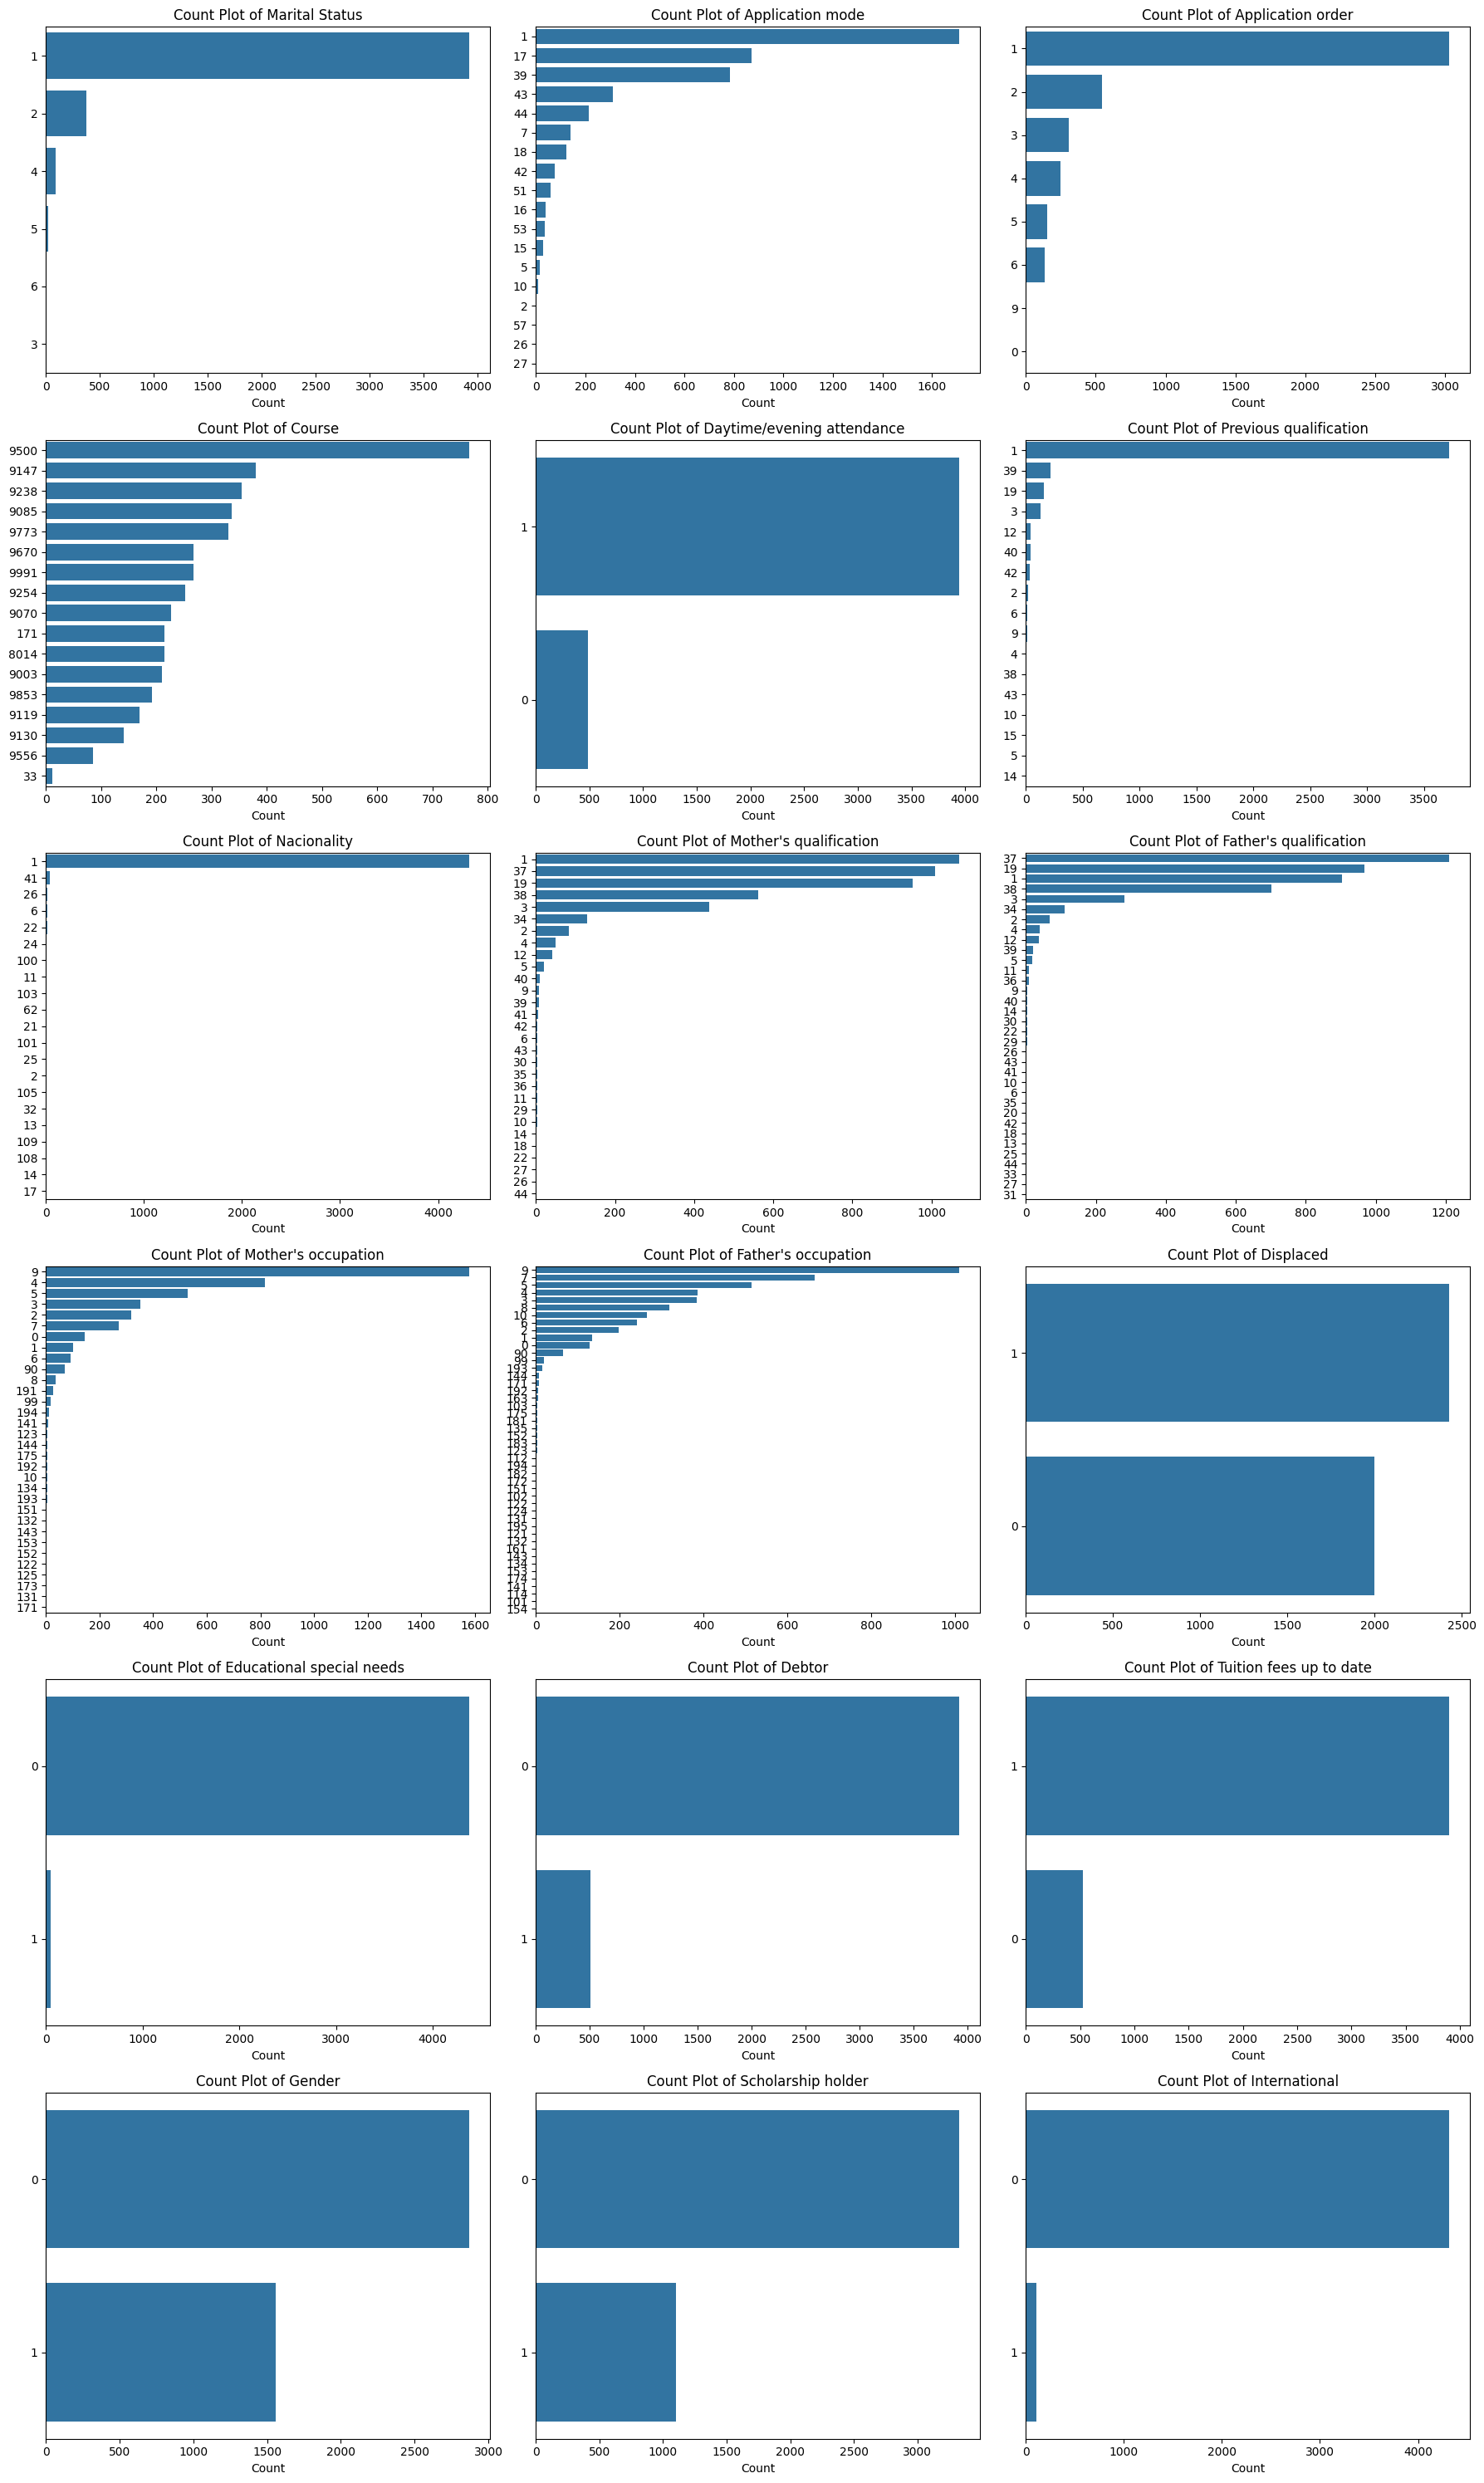

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Determine the number of rows and columns for the subplots
n_cols = 3  # For example, 3 columns per row
n_rows = (len(categorical_features) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 5))
for i, col in enumerate(categorical_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Count Plot of {col}')
    plt.xlabel('Count')
    plt.ylabel('') # Remove y-label to avoid clutter
plt.tight_layout()
plt.show()

## Remove Duplicate Rows



In [ ]:
print(f"Initial number of rows: {df.shape[0]}")
duplicate_rows = df.duplicated().sum()

if duplicate_rows > 0:
    print(f"Number of duplicate rows found: {duplicate_rows}")
    df_cleaned = df.drop_duplicates().copy()
    print(f"Number of rows after removing duplicates: {df_cleaned.shape[0]}")
    df = df_cleaned
else:
    print("No duplicate rows found.")

Initial number of rows: 4424
No duplicate rows found.


## Handle Outliers in Numerical Features



In [ ]:
for col in numerical_for_outliers:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Descriptive statistics for numerical columns after 1st and 99th percentile capping:")
print(df[numerical_for_outliers].describe())

Descriptive statistics for numerical columns after 1st and 99th percentile capping:
       Previous qualification (grade)  Admission grade  \
count                     4424.000000      4424.000000   
mean                       132.565077       126.926378   
std                         13.004846        14.186372   
min                        100.000000        99.000000   
25%                        125.000000       117.900000   
50%                        133.100000       126.100000   
75%                        140.000000       134.800000   
max                        170.000000       166.831000   

       Curricular units 1st sem (grade)  Curricular units 2nd sem (grade)  \
count                       4424.000000                       4424.000000   
mean                          10.634238                         10.224007   
std                            4.835557                          5.203243   
min                            0.000000                          0.000000   
25%     

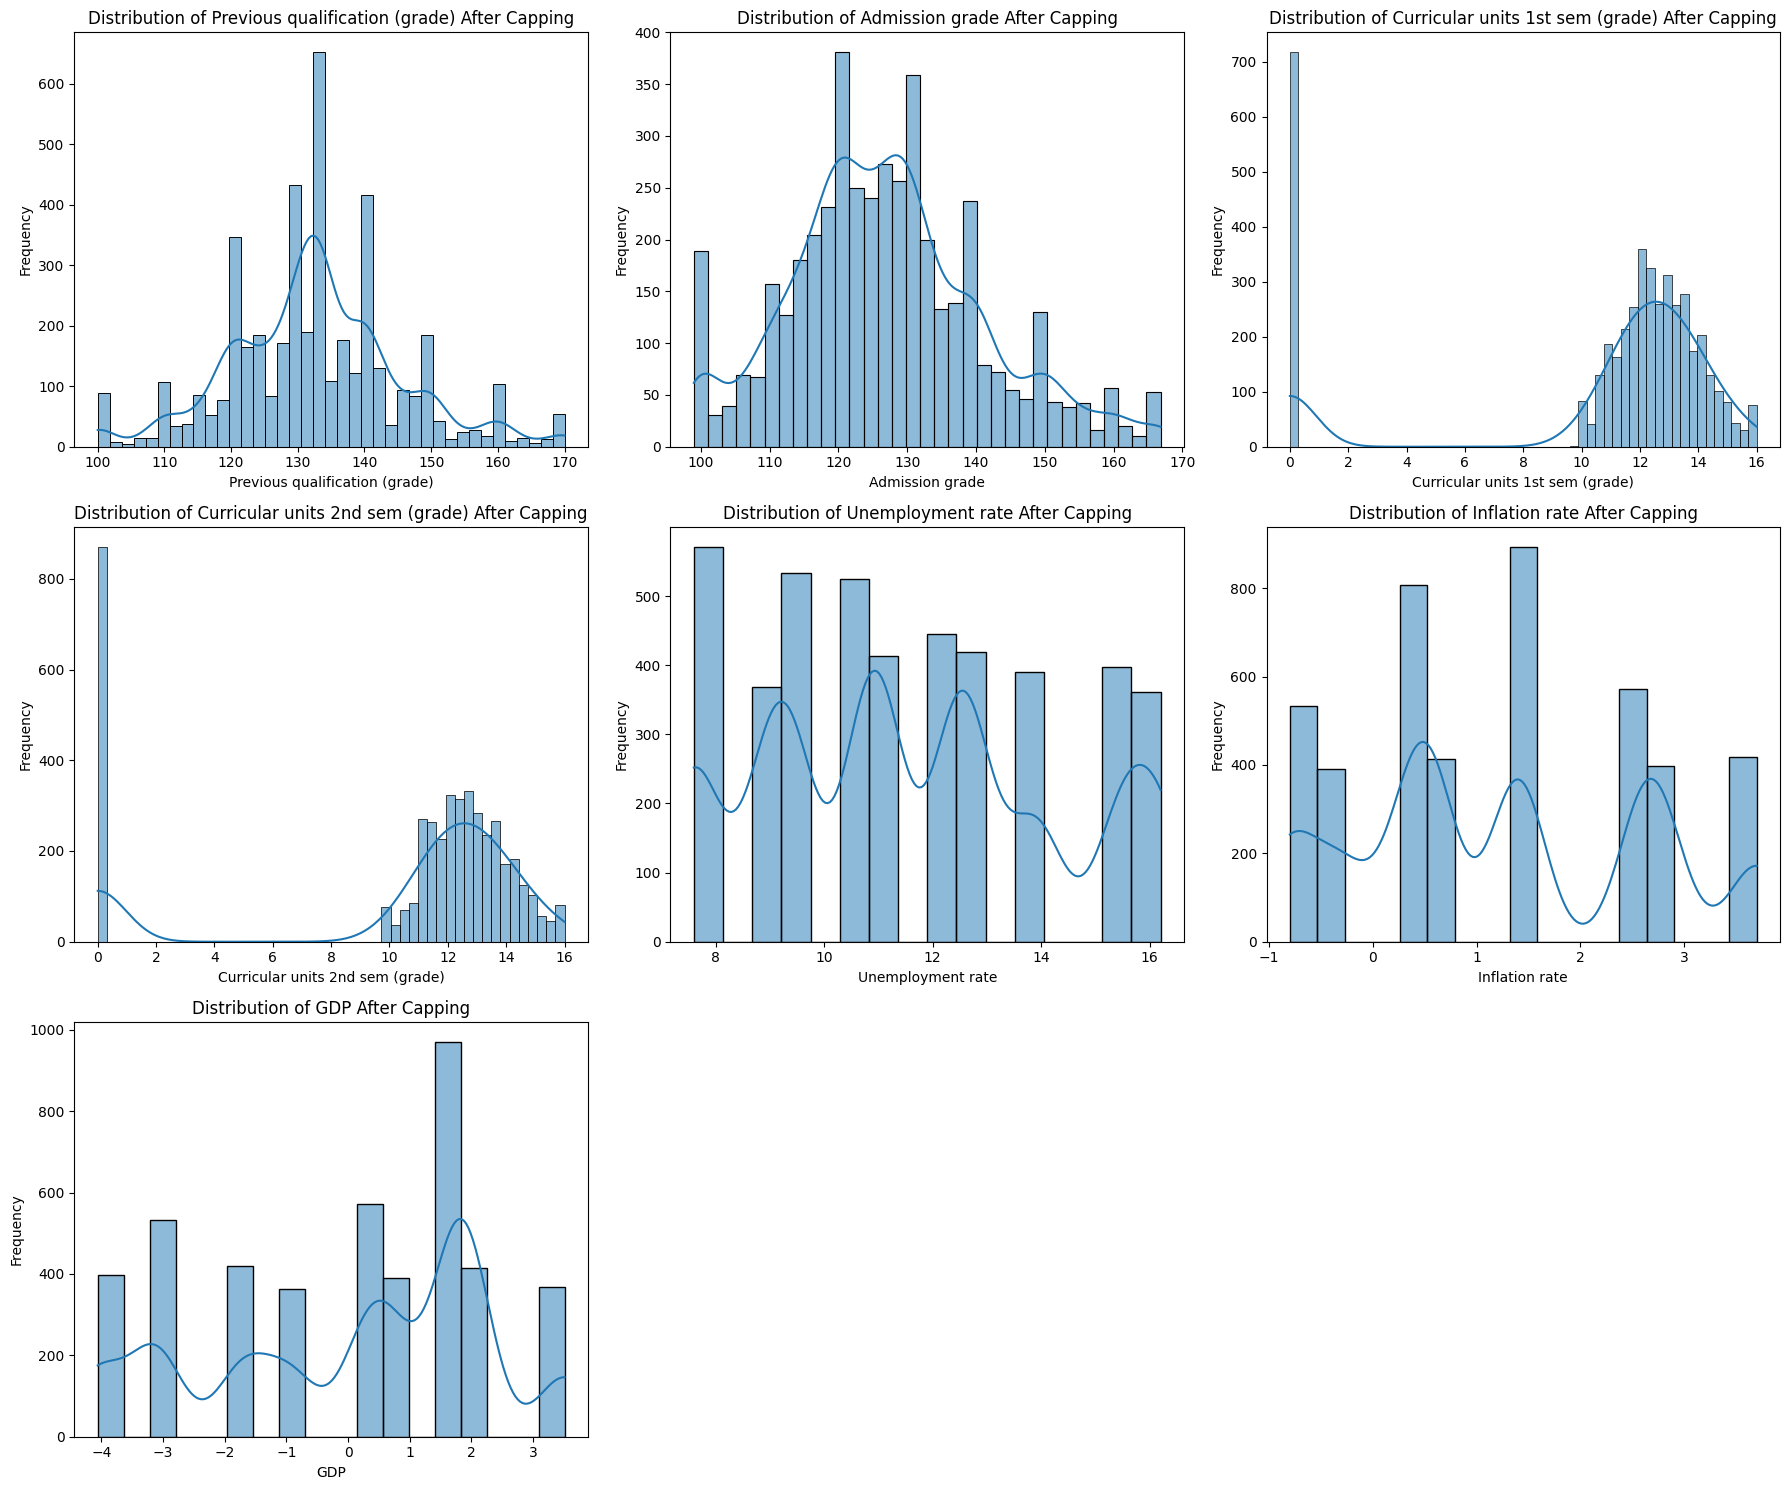

In [ ]:
n_cols = 3  # Number of columns for the grid
n_rows = (len(numerical_for_outliers) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 5))
for i, col in enumerate(numerical_for_outliers):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col} After Capping')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Encode Categorical Features




In [ ]:
print(f"Shape of DataFrame before one-hot encoding: {df.shape}")

# Apply one-hot encoding to the identified categorical features
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print(f"\nShape of DataFrame after one-hot encoding: {df_encoded.shape}")
print("\nFirst 5 rows of the DataFrame after one-hot encoding:")
print(df_encoded.head())

Shape of DataFrame before one-hot encoding: (4424, 37)

Shape of DataFrame after one-hot encoding: (4424, 245)

First 5 rows of the DataFrame after one-hot encoding:
   Previous qualification (grade)  Admission grade  Age at enrollment  \
0                           122.0            127.3                 20   
1                           160.0            142.5                 19   
2                           122.0            124.8                 19   
3                           122.0            119.6                 20   
4                           100.0            141.5                 45   

   Curricular units 1st sem (credited)  Curricular units 1st sem (enrolled)  \
0                                    0                                    0   
1                                    0                                    6   
2                                    0                                    6   
3                                    0                                    6   
